# 01 — Exploración de Datos

**Proyecto:** Anticipación de Costos Operativos — DataKnow  
**Fase:** 2 — Análisis Exploratorio de Datos (EDA)  
**Dataset:** `historico_equipos.csv`  
**Objetivo:** Entender el comportamiento histórico de precios de materias primas X, Y y Z, y de los equipos 1 y 2. Identificar patrones temporales, correlaciones y formular hipótesis de negocio.

---

## Contenido

1. [Carga de librerías](#1)
2. [Carga del dataset](#2)
3. [Revisión inicial](#3)
4. [Preprocesamiento básico](#4)
5. [Validación de calidad de datos](#5)
6. [Rango temporal y frecuencia](#6)
7. [Series temporales](#7)
8. [Análisis de correlaciones](#8)
9. [Hipótesis de negocio](#9)
10. [Guardado del dataset limpio](#10)

In [2]:
import sys
print(sys.executable)

c:\Users\Maria Jose\Desktop\dataknow-costos-operativos\.venv\Scripts\python.exe


---
<a id='1'></a>
## 1. Carga de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Configuración de visualización
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Rutas del proyecto
RAW_PATH       = Path('../data/raw')
PROCESSED_PATH = Path('../data/processed')
REPORTS_PATH   = Path('../reports')

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
<a id='2'></a>
## 2. Carga del Dataset

In [4]:
df = pd.read_csv(RAW_PATH / 'historico_equipos.csv')

print(f'Dataset cargado exitosamente.')
print(f'  Filas    : {df.shape[0]:,}')
print(f'  Columnas : {df.shape[1]}')
print(f'  Nombres  : {list(df.columns)}')

Dataset cargado exitosamente.
  Filas    : 3,530
  Columnas : 6
  Nombres  : ['Date', 'Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']


---
<a id='3'></a>
## 3. Revisión Inicial

Inspeccionamos las primeras y últimas filas, los tipos de datos y las estadísticas descriptivas
para tener una primera impresión del dataset antes de cualquier transformación.

In [5]:
# Primeras filas
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.1200,527.5000,2225.2500,434.7300,931.7300
1,2010-01-05,80.5900,527.5000,2246.5000,449.9700,968.5600
2,2010-01-06,81.8900,527.5000,2302.5000,444.4800,960.5100
3,2010-01-07,81.5100,527.5000,2306.5000,440.9000,960.1400
4,2010-01-08,81.3700,552.5000,2261.2500,448.8200,949.5500


In [6]:
# Últimas filas
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
3525,2023-08-25,84.4800,554.0000,2123.5000,450.3600,899.6500
3526,2023-08-28,84.4200,549.0000,2116.2500,469.0300,933.2000
3527,2023-08-29,85.4900,545.3300,2116.2500,460.4200,901.7900
3528,2023-08-30,85.8600,543.6700,2140.2500,464.8000,945.4000
3529,2023-08-31,86.8600,545.0000,2165.2500,451.7300,955.3500


In [7]:
# Tipos de datos, conteo de no nulos y uso de memoria
print('=== Información del dataset ===')
df.info()

=== Información del dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 3530 entries, 0 to 3529
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           3530 non-null   str    
 1   Price_X        3530 non-null   float64
 2   Price_Y        3530 non-null   float64
 3   Price_Z        3530 non-null   float64
 4   Price_Equipo1  3530 non-null   float64
 5   Price_Equipo2  3530 non-null   float64
dtypes: float64(5), str(1)
memory usage: 200.1 KB


In [8]:
# Estadísticas descriptivas — todas las columnas numéricas
# Incluye media, desviación estándar, mínimo, cuartiles y máximo
print('=== Estadísticas descriptivas ===')
df.describe().T

=== Estadísticas descriptivas ===


,count,mean,std,min,25%,50%,75%,max
Price_X,3530.0000,78.0910,25.1869,19.3300,57.0525,75.4000,104.5825,127.9800
Price_Y,3530.0000,555.5271,138.4890,257.5000,482.5000,541.6250,620.0000,1062.3700
Price_Z,3530.0000,2037.4321,373.1404,1421.5000,1767.2500,1974.7500,2235.9375,3984.0000
Price_Equipo1,3530.0000,460.0369,113.6813,208.3400,398.2275,451.2500,515.6075,855.3200
Price_Equipo2,3530.0000,889.9804,170.0427,566.0000,777.7025,869.7850,979.1225,1703.9600


---
<a id='4'></a>
## 4. Preprocesamiento Básico

### 4.1 Conversión de `Date` a formato datetime

La columna `Date` viene como texto (`object`). La convertimos a `datetime64` para poder
operar sobre ella con funciones temporales de pandas.

In [9]:
tipo_antes = df['Date'].dtype
df['Date'] = pd.to_datetime(df['Date'])
tipo_despues = df['Date'].dtype

print(f'Tipo de Date:  {tipo_antes}  →  {tipo_despues}')
print(f'Primera fecha : {df["Date"].min().date()}')
print(f'Última fecha  : {df["Date"].max().date()}')

Tipo de Date:  str  →  datetime64[us]
Primera fecha : 2010-01-04
Última fecha  : 2023-08-31


### 4.2 Ordenamiento cronológico

In [10]:
df = df.sort_values('Date').reset_index(drop=True)

print('Dataset ordenado cronológicamente (ascendente) y con índice reseteado.')
df[['Date']].head(3)

Dataset ordenado cronológicamente (ascendente) y con índice reseteado.


,Date
0,2010-01-04
1,2010-01-05
2,2010-01-06


---
<a id='5'></a>
## 5. Validación de Calidad de Datos

### 5.1 Valores faltantes

In [11]:
missing_abs = df.isnull().sum()
missing_pct = (missing_abs / len(df) * 100).round(2)

resumen_missing = pd.DataFrame({
    'Valores nulos': missing_abs,
    '% del total'  : missing_pct
})

print('=== Valores faltantes por columna ===')
display(resumen_missing)

if missing_abs.sum() == 0:
    print('\n✓ No se encontraron valores faltantes en el dataset.')
else:
    print(f'\n⚠  Se encontraron {missing_abs.sum()} valores faltantes. '
          'Evaluar estrategia de imputación antes de modelar.')

=== Valores faltantes por columna ===


,Valores nulos,% del total
Date,0,0.0000
Price_X,0,0.0000
Price_Y,0,0.0000
Price_Z,0,0.0000
Price_Equipo1,0,0.0000
Price_Equipo2,0,0.0000



✓ No se encontraron valores faltantes en el dataset.


### 5.2 Registros duplicados

In [12]:
n_dup_filas  = df.duplicated().sum()           # Filas completas repetidas
n_dup_fechas = df['Date'].duplicated().sum()   # Misma fecha con distintos valores

print(f'Filas completamente duplicadas : {n_dup_filas}')
print(f'Fechas duplicadas              : {n_dup_fechas}')

if n_dup_filas == 0 and n_dup_fechas == 0:
    print('\n✓ No se encontraron registros duplicados.')
else:
    print('\n⚠  Se encontraron duplicados — revisar antes de continuar.')

Filas completamente duplicadas : 0
Fechas duplicadas              : 0

✓ No se encontraron registros duplicados.


---
<a id='6'></a>
## 6. Rango Temporal y Frecuencia

Determinamos el período que cubre el dataset y la frecuencia de los registros
(diaria, semanal, mensual, etc.) analizando los intervalos entre fechas consecutivas.

In [13]:
fecha_inicio = df['Date'].min()
fecha_fin    = df['Date'].max()
duracion_d   = (fecha_fin - fecha_inicio).days

print('=== Rango temporal ===')
print(f'  Fecha de inicio : {fecha_inicio.date()}')
print(f'  Fecha de fin    : {fecha_fin.date()}')
print(f'  Duración total  : {duracion_d:,} días  (~{duracion_d/365:.1f} años)')
print(f'  Registros       : {len(df):,}')

=== Rango temporal ===
  Fecha de inicio : 2010-01-04
  Fecha de fin    : 2023-08-31
  Duración total  : 4,987 días  (~13.7 años)
  Registros       : 3,530


In [14]:
# Análisis de los intervalos entre fechas consecutivas
diffs = df['Date'].diff().dropna()

print('=== Distribución de intervalos entre fechas consecutivas ===')
print(diffs.value_counts().head(10).to_string())

print(f'\n  Mediana del intervalo : {diffs.median()}')
print(f'  Moda del intervalo    : {diffs.mode()[0]}')
print(f'  Intervalo máximo      : {diffs.max()}')

=== Distribución de intervalos entre fechas consecutivas ===
Date
1 days    2808
3 days     687
4 days      25
2 days       9

  Mediana del intervalo : 1 days 00:00:00
  Moda del intervalo    : 1 days 00:00:00
  Intervalo máximo      : 4 days 00:00:00


In [15]:
# Detectar gaps inusuales (más de 5 días — relevante para datos de días hábiles)
GAP_UMBRAL = pd.Timedelta(days=5)
gaps = diffs[diffs > GAP_UMBRAL]

if len(gaps) > 0:
    gap_df = pd.DataFrame({
        'Fecha'      : df['Date'][gaps.index].values,
        'Gap (días)' : gaps.dt.days.values
    })
    print(f'⚠  Se detectaron {len(gaps)} gaps mayores a {GAP_UMBRAL.days} días:')
    display(gap_df)
else:
    print(f'✓ No se detectaron gaps mayores a {GAP_UMBRAL.days} días.')

✓ No se detectaron gaps mayores a 5 días.


---
<a id='7'></a>
## 7. Series Temporales

Visualizamos la evolución histórica de cada variable para identificar tendencias,
cambios de régimen, volatilidad y posibles outliers temporales.

La línea discontinua negra representa la **media móvil de 90 días**, útil para
suavizar el ruido y revelar la tendencia subyacente.

### 7.1 Series de materias primas (Price_X, Price_Y, Price_Z)

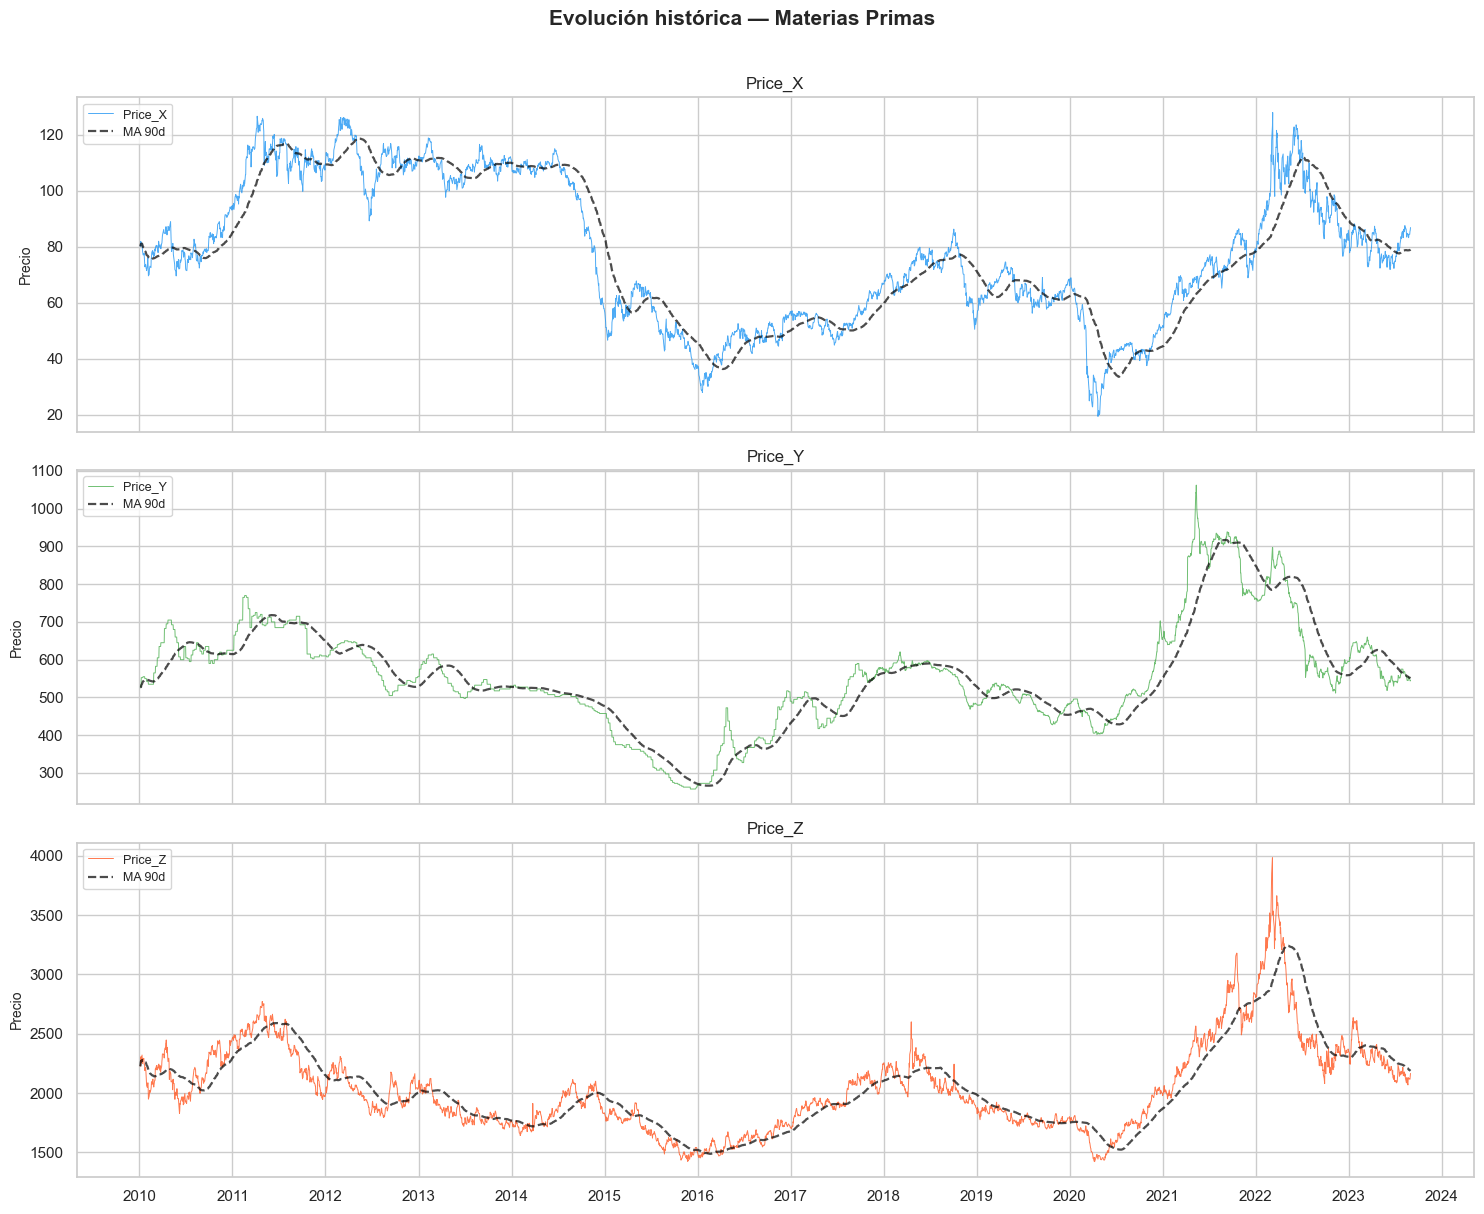

In [16]:
MATERIAS_PRIMAS = ['Price_X', 'Price_Y', 'Price_Z']
EQUIPOS         = ['Price_Equipo1', 'Price_Equipo2']
TODAS           = MATERIAS_PRIMAS + EQUIPOS

COLORES = {
    'Price_X'      : '#2196F3',  # Azul
    'Price_Y'      : '#4CAF50',  # Verde
    'Price_Z'      : '#FF5722',  # Naranja oscuro
    'Price_Equipo1': '#9C27B0',  # Morado
    'Price_Equipo2': '#FF9800',  # Naranja
}

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Evolución histórica — Materias Primas', fontsize=15, fontweight='bold', y=1.01)

for ax, col in zip(axes, MATERIAS_PRIMAS):
    # Serie original
    ax.plot(df['Date'], df[col], color=COLORES[col], linewidth=0.7, alpha=0.8, label=col)
    # Media móvil 90 días para visualizar tendencia
    ma90 = df[col].rolling(window=90, min_periods=1).mean()
    ax.plot(df['Date'], ma90, color='black', linewidth=1.6,
            linestyle='--', alpha=0.7, label='MA 90d')
    ax.set_ylabel('Precio', fontsize=10)
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_series_materias_primas.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.2 Series de equipos (Price_Equipo1, Price_Equipo2)

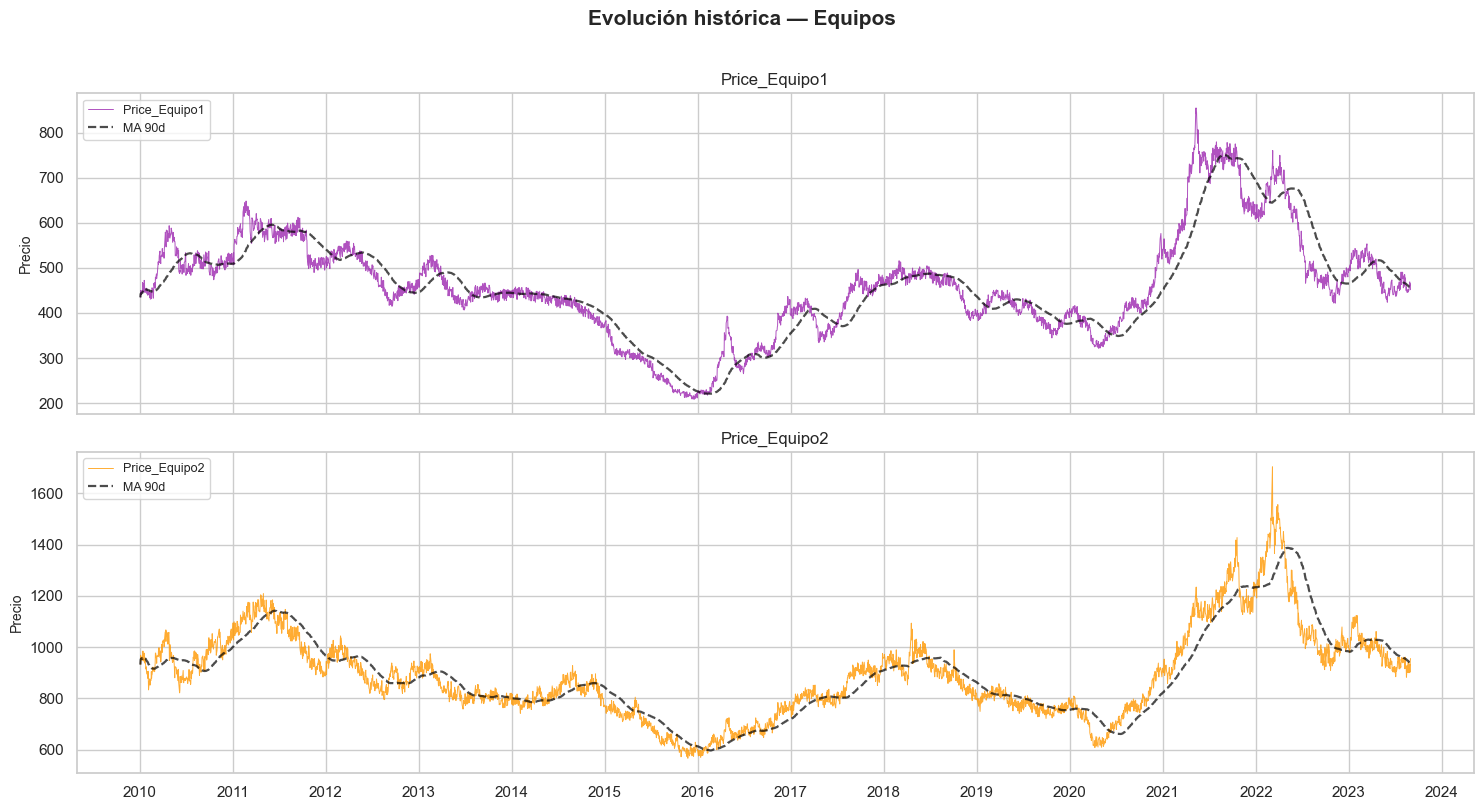

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Evolución histórica — Equipos', fontsize=15, fontweight='bold', y=1.01)

for ax, col in zip(axes, EQUIPOS):
    ax.plot(df['Date'], df[col], color=COLORES[col], linewidth=0.7, alpha=0.8, label=col)
    ma90 = df[col].rolling(window=90, min_periods=1).mean()
    ax.plot(df['Date'], ma90, color='black', linewidth=1.6,
            linestyle='--', alpha=0.7, label='MA 90d')
    ax.set_ylabel('Precio', fontsize=10)
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_series_equipos.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.3 Todas las variables normalizadas — Base 100

Normalizar a base 100 desde el primer período permite comparar las dinámicas relativas
de variables que tienen escalas muy distintas (e.g. Price_Z vs. Price_X).

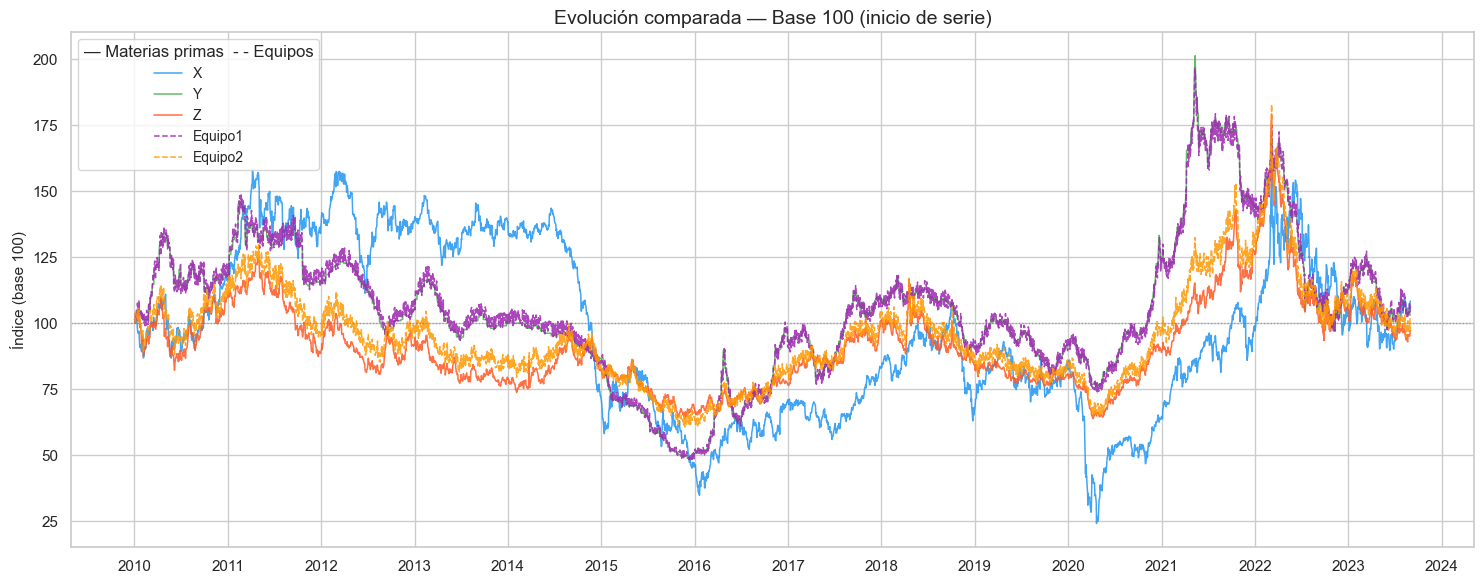

In [18]:
# Normalización: cada serie dividida por su primer valor × 100
primera_fila = df[TODAS].iloc[0]
df_norm = df[TODAS].div(primera_fila) * 100

fig, ax = plt.subplots(figsize=(15, 6))

for col in TODAS:
    estilo = '-' if col in MATERIAS_PRIMAS else '--'
    ax.plot(df['Date'], df_norm[col],
            label=col.replace('Price_', ''),
            color=COLORES[col],
            linewidth=1.1,
            linestyle=estilo,
            alpha=0.85)

ax.axhline(100, color='gray', linestyle=':', linewidth=0.9, alpha=0.7)
ax.set_title('Evolución comparada — Base 100 (inicio de serie)', fontsize=14)
ax.set_ylabel('Índice (base 100)')
ax.legend(loc='upper left', fontsize=10,
          title='— Materias primas  - - Equipos')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_series_base100.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.4 Distribuciones de precios (histograma + KDE)

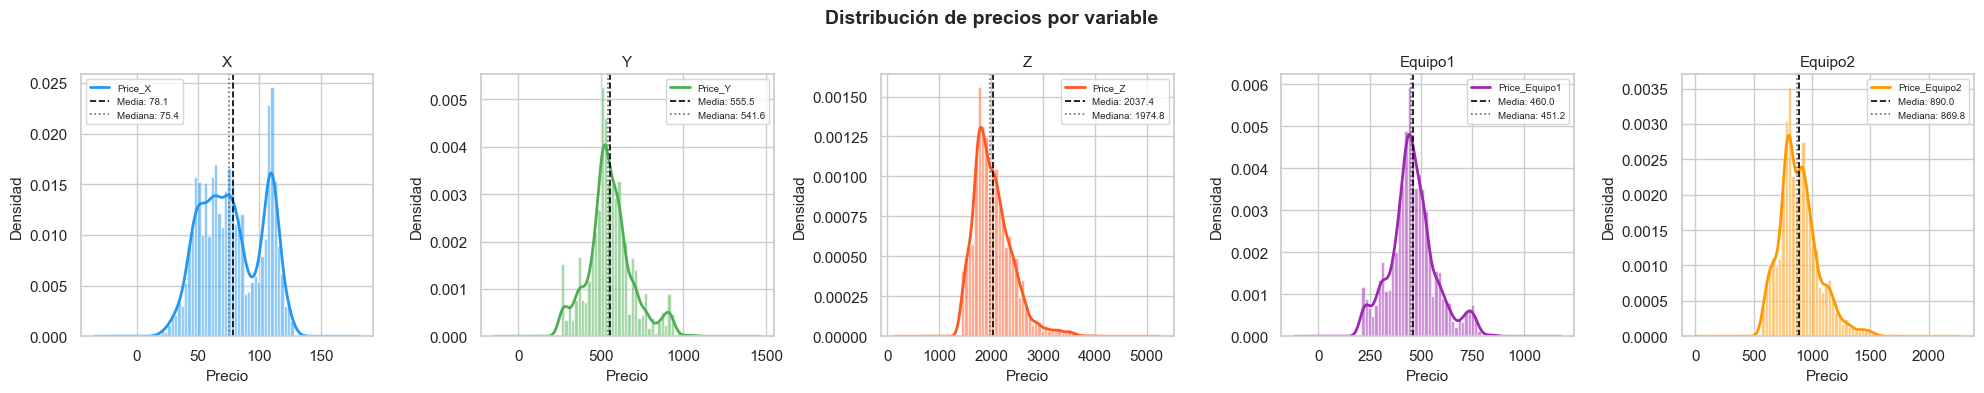

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribución de precios por variable', fontsize=14, fontweight='bold')

for ax, col in zip(axes, TODAS):
    datos = df[col].dropna()
    color = COLORES[col]

    ax.hist(datos, bins=40, color=color, alpha=0.55, edgecolor='white', density=True)
    datos.plot.kde(ax=ax, color=color, linewidth=2)

    # Líneas de media y mediana
    ax.axvline(datos.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Media: {datos.mean():.1f}')
    ax.axvline(datos.median(), color='dimgray', linestyle=':',  linewidth=1.2, label=f'Mediana: {datos.median():.1f}')

    ax.set_title(col.replace('Price_', ''), fontsize=11)
    ax.set_xlabel('Precio')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.5 Boxplots por año — Cambios en la distribución a lo largo del tiempo

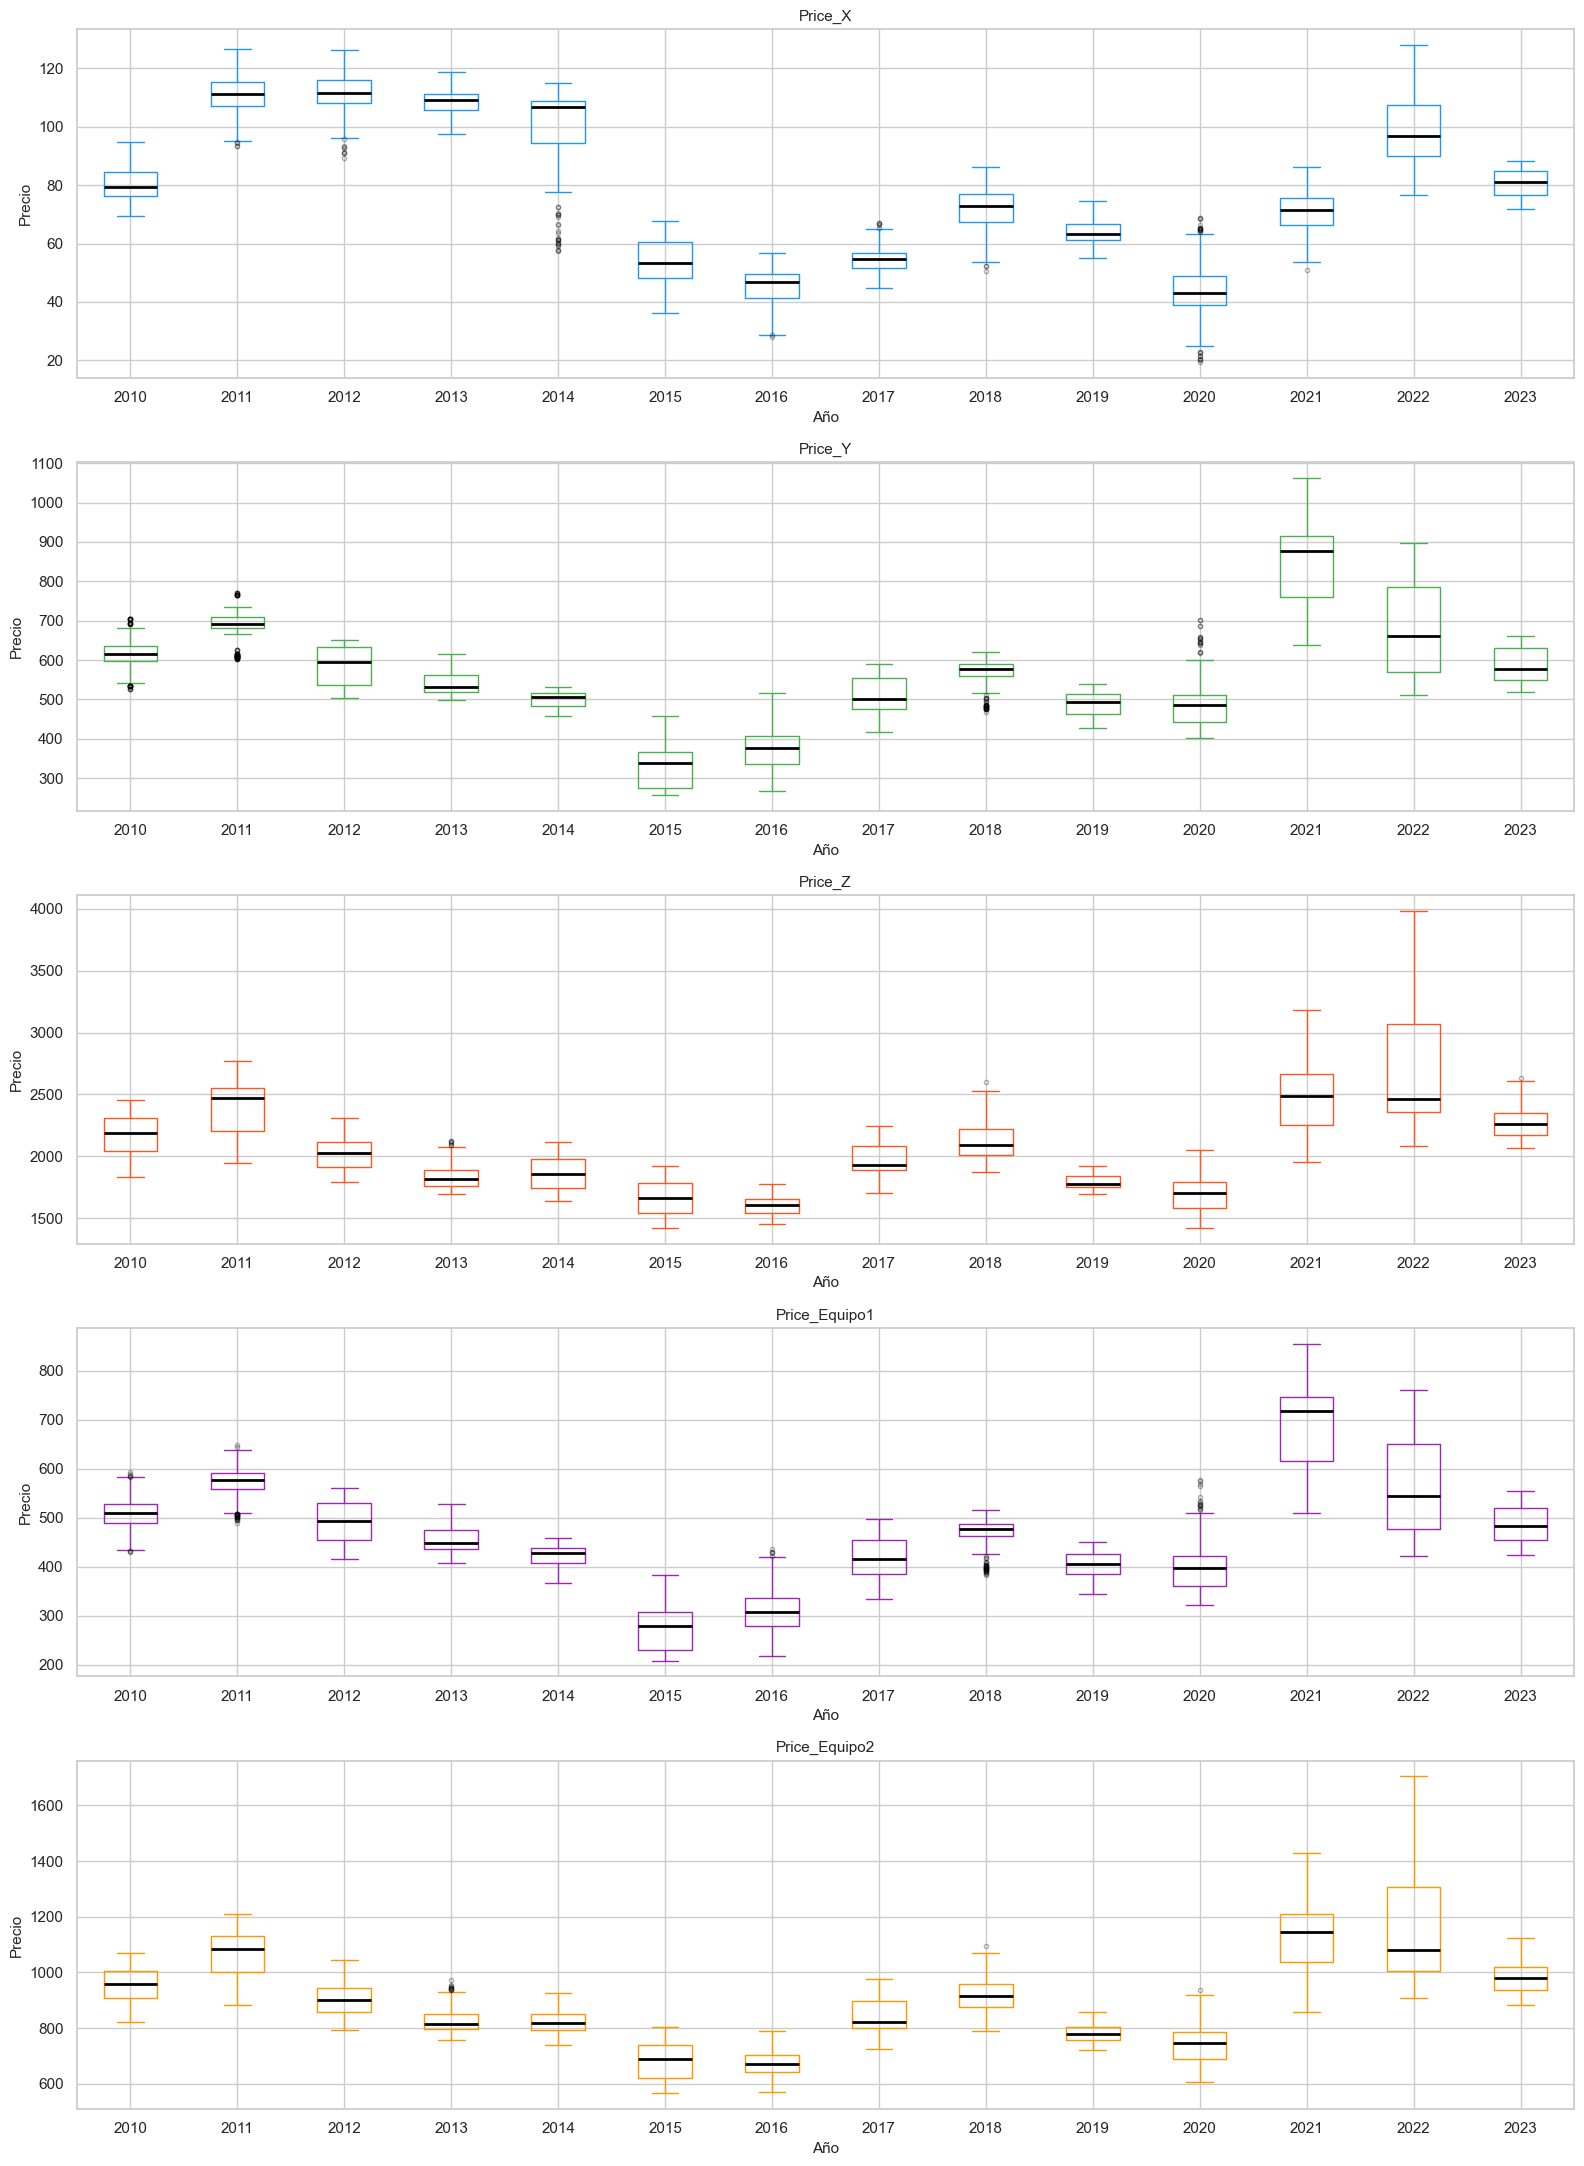

In [20]:
# Columna auxiliar de año para agrupar
df['Year'] = df['Date'].dt.year

fig, axes = plt.subplots(5, 1, figsize=(16, 22))
fig.suptitle('Distribución por año — Detección de cambios de régimen',
             fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes, TODAS):
    color = COLORES[col]
    df.boxplot(
        column=col, by='Year', ax=ax,
        boxprops=dict(color=color),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', color=color, alpha=0.3, markersize=3)
    )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Año')
    ax.set_ylabel('Precio')

plt.suptitle('')  # Eliminar el supertítulo automático de pandas boxplot
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_boxplots_anuales.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='8'></a>
## 8. Análisis de Correlaciones

Evaluamos la relación lineal (Pearson) y monótona (Spearman) entre todas las variables.
La pregunta central es: **¿qué materias primas están más relacionadas con el precio de cada equipo?**

### 8.1 Matriz de correlación de Pearson (niveles)

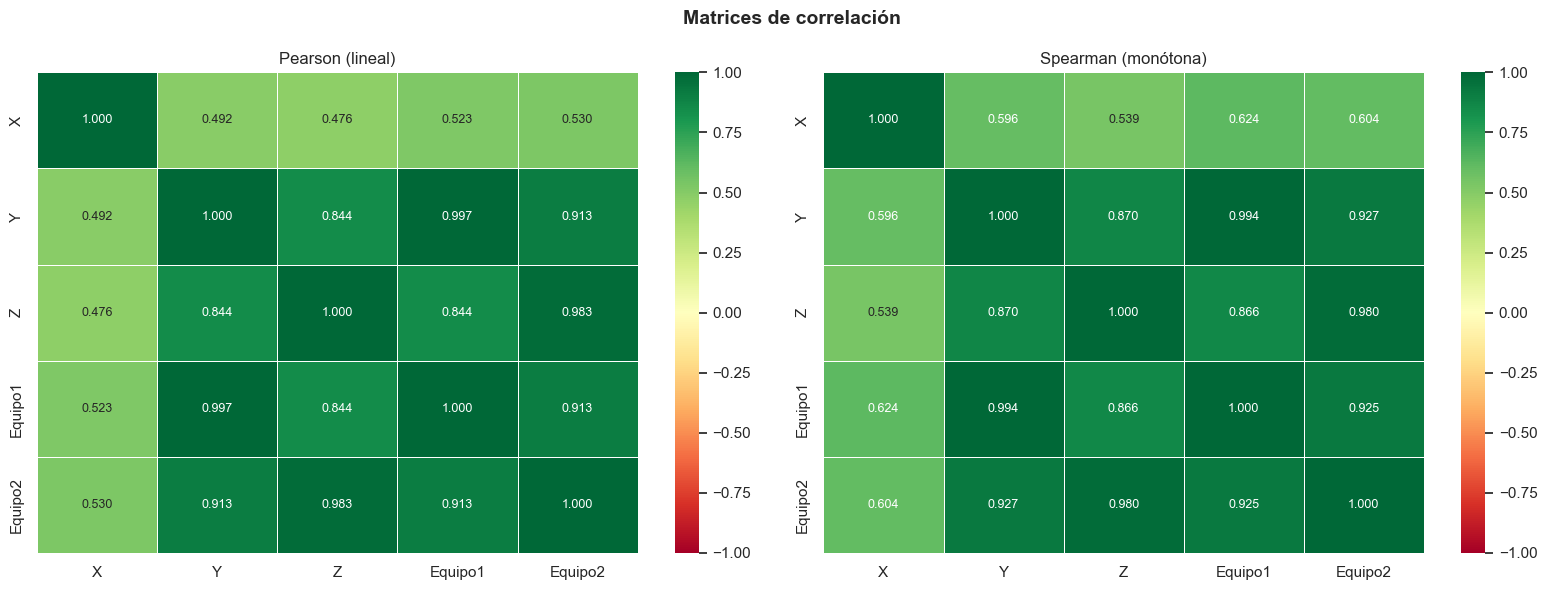

In [21]:
corr_pearson  = df[TODAS].corr(method='pearson')
corr_spearman = df[TODAS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrices de correlación', fontsize=14, fontweight='bold')

for ax, corr, titulo in zip(axes,
                             [corr_pearson, corr_spearman],
                             ['Pearson (lineal)', 'Spearman (monótona)']):
    sns.heatmap(
        corr,
        annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        ax=ax, linewidths=0.5,
        annot_kws={'size': 9},
        xticklabels=[c.replace('Price_', '') for c in corr.columns],
        yticklabels=[c.replace('Price_', '') for c in corr.index]
    )
    ax.set_title(titulo, fontsize=12)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_matrices_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.2 Correlación específica: materias primas vs. equipos

Extraemos la submatriz que responde directamente la pregunta de negocio.

In [22]:
corr_mp_eq_p = corr_pearson.loc[MATERIAS_PRIMAS, EQUIPOS]
corr_mp_eq_s = corr_spearman.loc[MATERIAS_PRIMAS, EQUIPOS]

print('=== Pearson — Materias Primas vs. Equipos ===')
display(corr_mp_eq_p.rename(
    index=lambda x: x.replace('Price_',''),
    columns=lambda x: x.replace('Price_','')
).style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1).format('{:.4f}'))

print('\n=== Spearman — Materias Primas vs. Equipos ===')
display(corr_mp_eq_s.rename(
    index=lambda x: x.replace('Price_',''),
    columns=lambda x: x.replace('Price_','')
).style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1).format('{:.4f}'))

=== Pearson — Materias Primas vs. Equipos ===


,Equipo1,Equipo2
X,0.5234,0.5303
Y,0.9966,0.9127
Z,0.8440,0.9827



=== Spearman — Materias Primas vs. Equipos ===


,Equipo1,Equipo2
X,0.6241,0.6037
Y,0.9942,0.9271
Z,0.8663,0.9797


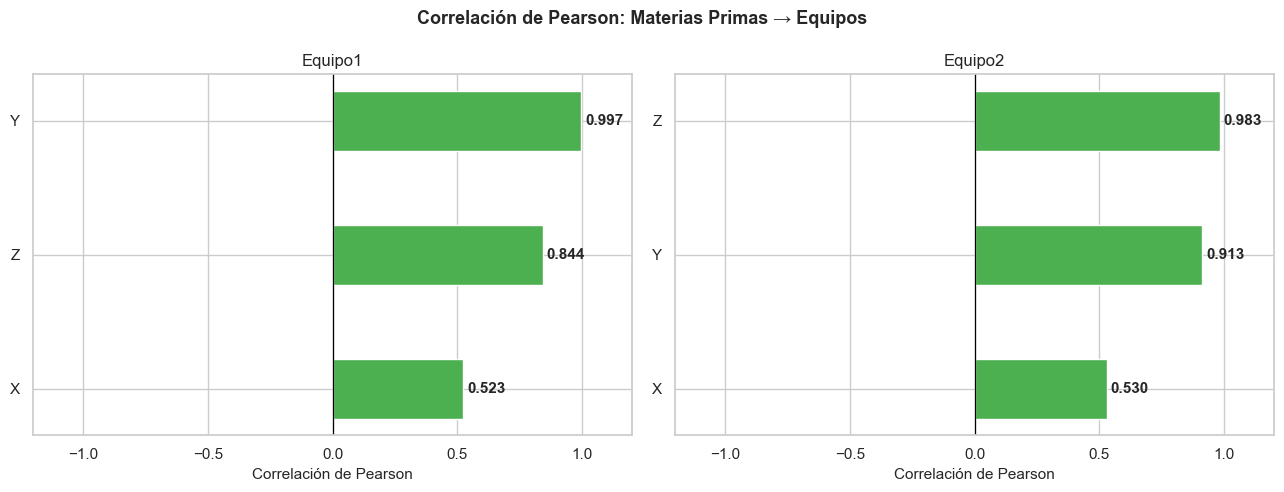

In [23]:
# Gráfico de barras: correlación de cada materia prima con cada equipo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Correlación de Pearson: Materias Primas → Equipos',
             fontsize=13, fontweight='bold')

for ax, equipo in zip(axes, EQUIPOS):
    valores = corr_mp_eq_p[equipo].sort_values(ascending=True)
    etiquetas = valores.index.str.replace('Price_', '')
    colores_barra = ['#4CAF50' if v >= 0 else '#F44336' for v in valores]

    bars = ax.barh(etiquetas, valores.values, color=colores_barra,
                   edgecolor='white', height=0.45)
    ax.axvline(0, color='black', linewidth=0.9)

    # Etiquetas de valor
    for bar, val in zip(bars, valores.values):
        offset = 0.015 if val >= 0 else -0.015
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha=ha, fontsize=11, fontweight='bold')

    ax.set_xlim(-1.2, 1.2)
    ax.set_title(equipo.replace('Price_', ''), fontsize=12)
    ax.set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_correlacion_mp_equipos.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.3 Scatter plots: materias primas vs. equipos

Verificamos visualmente la forma de la relación (lineal, curvilínea, sin relación)
y detectamos posibles outliers bivariados.

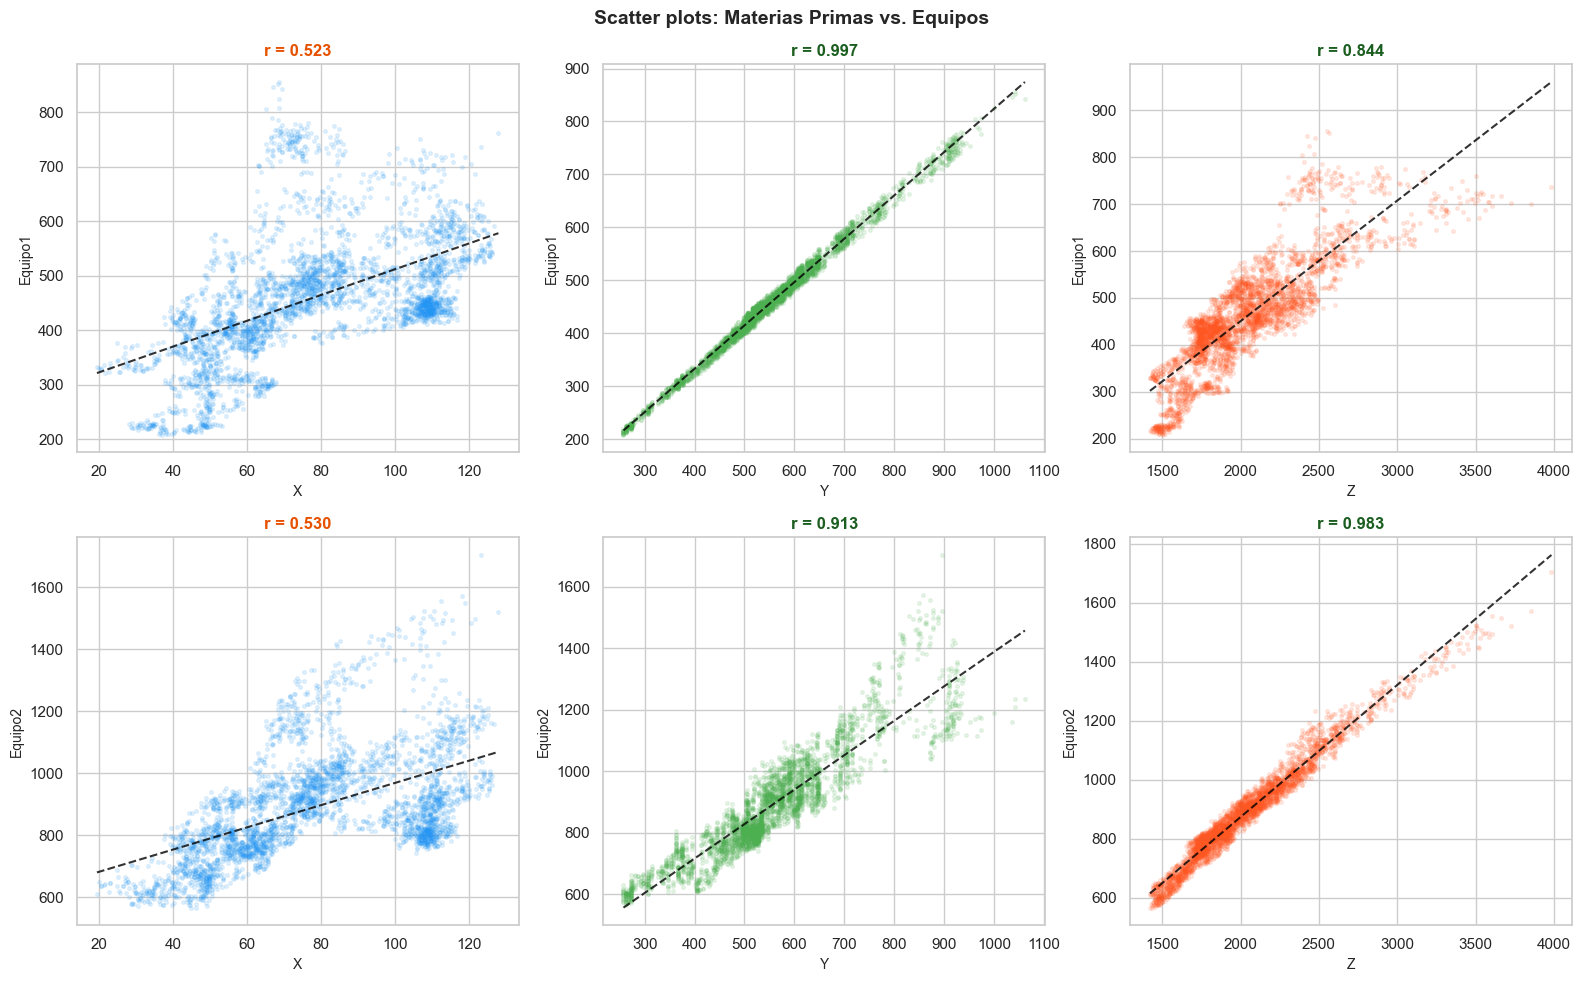

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Scatter plots: Materias Primas vs. Equipos', fontsize=14, fontweight='bold')

for fila, equipo in enumerate(EQUIPOS):
    for col_idx, mp in enumerate(MATERIAS_PRIMAS):
        ax = axes[fila, col_idx]
        r  = corr_pearson.loc[mp, equipo]

        ax.scatter(df[mp], df[equipo],
                   alpha=0.12, s=7, color=COLORES[mp])

        # Línea de tendencia (regresión lineal simple)
        mask = df[mp].notna() & df[equipo].notna()
        z = np.polyfit(df.loc[mask, mp], df.loc[mask, equipo], 1)
        x_line = np.linspace(df[mp].min(), df[mp].max(), 100)
        ax.plot(x_line, np.poly1d(z)(x_line),
                color='black', linewidth=1.5, linestyle='--', alpha=0.8)

        ax.set_xlabel(mp.replace('Price_', ''), fontsize=10)
        ax.set_ylabel(equipo.replace('Price_', ''), fontsize=10)

        # Color del título según fuerza de correlación
        if abs(r) > 0.7:
            color_titulo = '#1B5E20'   # Verde oscuro — alta
        elif abs(r) > 0.4:
            color_titulo = '#E65100'   # Naranja — moderada
        else:
            color_titulo = '#B71C1C'   # Rojo — baja

        ax.set_title(f'r = {r:.3f}', fontsize=12, color=color_titulo, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_scatter_mp_equipos.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.4 Correlación rodante (ventana 365 días) — Estabilidad de las relaciones

Una correlación global alta pero inestable en el tiempo indica que el modelo puede
degradarse si se entrena en un período que no represente el comportamiento actual.

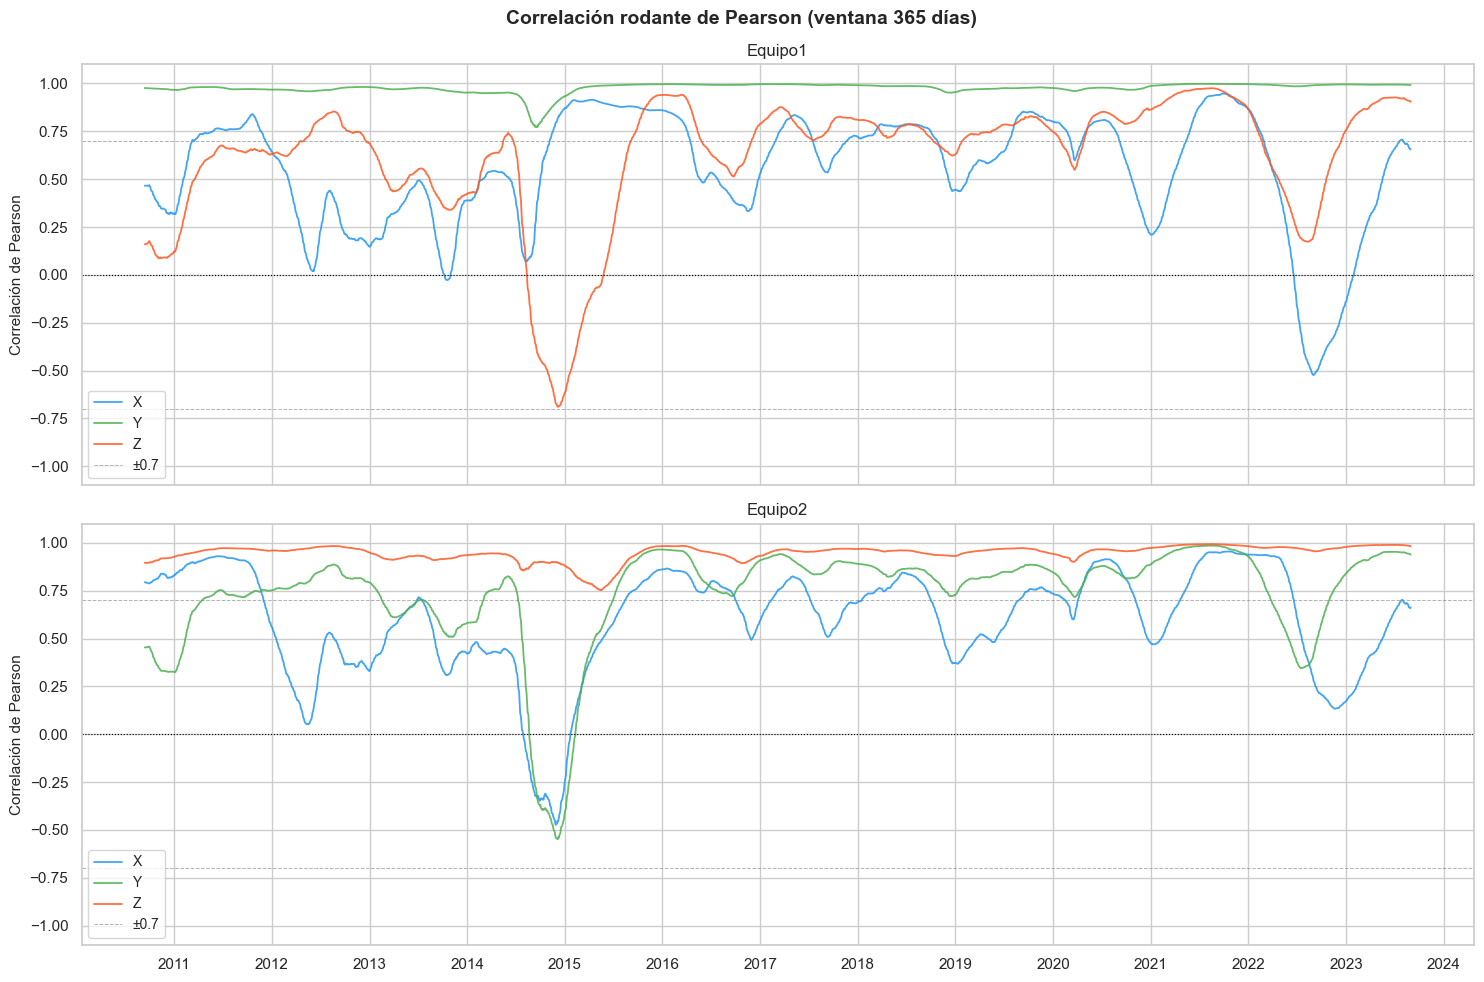

In [25]:
WINDOW = 365  # días

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f'Correlación rodante de Pearson (ventana {WINDOW} días)',
             fontsize=14, fontweight='bold')

for ax, equipo in zip(axes, EQUIPOS):
    for mp in MATERIAS_PRIMAS:
        roll_corr = df[mp].rolling(window=WINDOW, min_periods=180).corr(df[equipo])
        ax.plot(df['Date'], roll_corr,
                label=mp.replace('Price_', ''),
                color=COLORES[mp], linewidth=1.3, alpha=0.85)

    ax.axhline(0,    color='black', linewidth=0.8, linestyle=':')
    ax.axhline(0.7,  color='gray',  linewidth=0.7, linestyle='--', alpha=0.6, label='±0.7')
    ax.axhline(-0.7, color='gray',  linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel('Correlación de Pearson')
    ax.set_title(equipo.replace('Price_', ''), fontsize=12)
    ax.legend(fontsize=10, loc='lower left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_correlacion_rodante.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.5 Resumen tabular de correlaciones

In [26]:
filas = []
for mp in MATERIAS_PRIMAS:
    for eq in EQUIPOS:
        r_p = corr_pearson.loc[mp, eq]
        r_s = corr_spearman.loc[mp, eq]

        if   abs(r_p) > 0.9: fuerza = 'Muy alta'
        elif abs(r_p) > 0.7: fuerza = 'Alta'
        elif abs(r_p) > 0.4: fuerza = 'Moderada'
        else:                 fuerza = 'Baja'

        filas.append({
            'Materia prima' : mp.replace('Price_', ''),
            'Equipo'        : eq.replace('Price_', ''),
            'Pearson (r)'   : round(r_p, 4),
            'Spearman (ρ)'  : round(r_s, 4),
            'Fuerza'        : fuerza,
        })

resumen_corr = (
    pd.DataFrame(filas)
    .sort_values('Pearson (r)', key=abs, ascending=False)
    .reset_index(drop=True)
)

print('=== Resumen de correlaciones: Materias Primas → Equipos ===')
display(resumen_corr)

=== Resumen de correlaciones: Materias Primas → Equipos ===


,Materia prima,Equipo,Pearson (r),Spearman (ρ),Fuerza
0,Y,Equipo1,0.9966,0.9942,Muy alta
1,Z,Equipo2,0.9827,0.9797,Muy alta
2,Y,Equipo2,0.9127,0.9271,Muy alta
3,Z,Equipo1,0.8440,0.8663,Alta
4,X,Equipo2,0.5303,0.6037,Moderada
5,X,Equipo1,0.5234,0.6241,Moderada


### 8.6 Correlación entre materias primas — Evaluación de multicolinealidad

Si las materias primas están altamente correlacionadas entre sí, incluirlas todas
en un modelo de regresión puede causar inestabilidad numérica (multicolinealidad).
Esto se evaluará formalmente con el VIF en el notebook de modelado.

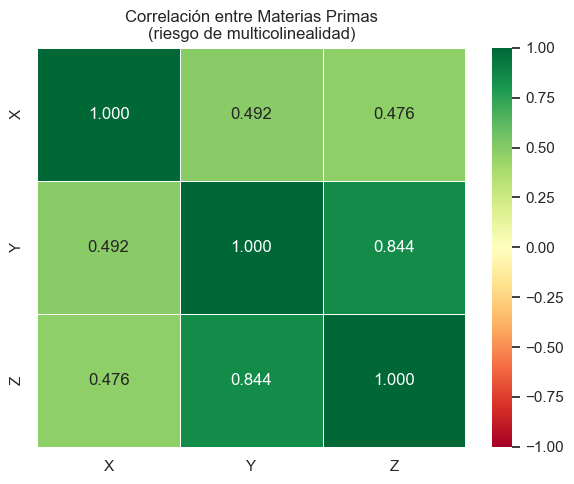

In [27]:
corr_entre_mp = corr_pearson.loc[MATERIAS_PRIMAS, MATERIAS_PRIMAS]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_entre_mp,
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5,
    annot_kws={'size': 12},
    xticklabels=[c.replace('Price_', '') for c in corr_entre_mp.columns],
    yticklabels=[c.replace('Price_', '') for c in corr_entre_mp.index]
)
ax.set_title('Correlación entre Materias Primas\n(riesgo de multicolinealidad)', fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_correlacion_entre_mp.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='9'></a>
## 9. Hipótesis de Negocio

Con base en el análisis anterior, formulamos hipótesis que guiarán la etapa de modelado.

### 9.1 Variables con mayor poder explicativo por equipo

In [28]:
print('=== Materia prima con mayor/menor correlación por equipo ===')
print()
for eq in EQUIPOS:
    corrs = corr_pearson.loc[MATERIAS_PRIMAS, eq].abs()
    mejor = corrs.idxmax()
    menor = corrs.idxmin()
    print(f'  {eq.replace("Price_", ""):12s}  │'
          f'  Mayor: {mejor.replace("Price_",""):4s} (r={corr_pearson.loc[mejor, eq]:+.4f})'
          f'  │  Menor: {menor.replace("Price_",""):4s} (r={corr_pearson.loc[menor, eq]:+.4f})')

=== Materia prima con mayor/menor correlación por equipo ===

  Equipo1       │  Mayor: Y    (r=+0.9966)  │  Menor: X    (r=+0.5234)
  Equipo2       │  Mayor: Z    (r=+0.9827)  │  Menor: X    (r=+0.5303)


### 9.2 Hipótesis formuladas

Las siguientes hipótesis se derivan del EDA y se validarán formalmente en la etapa de modelado:

---

**H1 — Dependencia selectiva de materias primas**  
Cada equipo tiene un subconjunto de materias primas que explica mejor su variación de precio.
No todas las materias primas son igualmente relevantes para ambos equipos.

---

**H2 — Posible efecto rezagado**  
El impacto de una variación en el precio de una materia prima puede tardar días o semanas
en reflejarse en el precio del equipo. Esto se evaluará mediante correlaciones con *lags*
en el notebook de modelado.

---

**H3 — Estabilidad temporal de las correlaciones**  
El análisis de correlación rodante sugiere que las relaciones entre variables
pueden variar a lo largo del tiempo. Los modelos entrenados en períodos más recientes
pueden ser más representativos del comportamiento actual del mercado.

---

**H4 — Tendencias de largo plazo**  
Las series muestran componentes de tendencia claros. Cualquier modelo predictivo
deberá capturar esta componente para evitar predicciones sesgadas.

---

**H5 — Riesgo de multicolinealidad**  
Si las materias primas están correlacionadas entre sí, incluirlas todas en un modelo
de regresión puede generar inestabilidad. Será necesario calcular el VIF
(Variance Inflation Factor) y considerar selección de variables o regularización (Ridge/Lasso).

---

---
<a id='10'></a>
## 10. Guardado del Dataset Limpio

In [29]:
# Eliminar columna auxiliar Year y guardar
df_limpio = df.drop(columns=['Year'], errors='ignore').copy()

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
output_path = PROCESSED_PATH / 'historico_equipos_limpio.csv'
df_limpio.to_csv(output_path, index=False)

print(f'✓ Dataset limpio guardado en: {output_path}')
print(f'  Filas    : {df_limpio.shape[0]:,}')
print(f'  Columnas : {df_limpio.shape[1]}')
print(f'  Nombres  : {list(df_limpio.columns)}')
print(f'  Período  : {df_limpio["Date"].min().date()} → {df_limpio["Date"].max().date()}')

✓ Dataset limpio guardado en: ..\data\processed\historico_equipos_limpio.csv
  Filas    : 3,530
  Columnas : 6
  Nombres  : ['Date', 'Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']
  Período  : 2010-01-04 → 2023-08-31


---

## Resumen del EDA

| Aspecto | Resultado |
|---|---|
| Período cubierto | Ver §6 |
| Frecuencia de datos | Diaria (días hábiles) |
| Valores faltantes | Ver §5.1 |
| Duplicados | Ver §5.2 |
| MP más correlacionada con Equipo 1 | Ver §9.1 |
| MP más correlacionada con Equipo 2 | Ver §9.1 |
| Riesgo de multicolinealidad | Ver §8.6 |
| Hipótesis formuladas | 5 (H1 – H5, ver §9.2) |
| Figuras generadas | `reports/fig_*.png` |
| Dataset limpio | `data/processed/historico_equipos_limpio.csv` |

**Siguiente paso:** `02_modelado_predictivo.ipynb` — entrenamiento, evaluación y selección de modelos.

---
*DataKnow — Anticipación de Costos Operativos · 2026*